# **scRNA DATA VIEWER**

For looking at umaps and other basic info without all of the overhead of the other scripts (will put this into git eventually)

In [1]:
#STEP 1: IMPORTS
#Load this first

import warnings
import scanpy as sc
import scanpy as sc
import anndata as ad
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import doubletdetection
import soupx
import harmonypy as hm
import decoupler as dc
import scvi
from IPython.display import clear_output 
import re
import os
import time
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

warnings.filterwarnings('ignore')
ad.settings.allow_write_nullable_strings = True
pd.options.future.infer_string = False
pd.reset_option("all")
%matplotlib inline

#COLOR DEFINITIONS
infected_colors = {
    "infected": "#582B36",
    "uninfected": "#582B36"
}

i_contrast_colors = ["#E2552D","#2E5283"]
ifitm_hex = ["#BEBDBD", "#DF3848"]
aggressive_hex = ["#FFFFFF","#000000"]

ifitm_cmap = mcolors.LinearSegmentedColormap.from_list("ifitm_cmap",ifitm_hex)
aggr_cmap = mcolors.LinearSegmentedColormap.from_list("aggr_cmap",aggressive_hex)

marker_genes = {
    "T Cells": ["Cd3e"],
    "B Cells": ["Cd19", "Cd74"],
    "Absorptive Colonocytes": ["Slc26a3","Aqp4","Aqp8","Cyp2c55","Car1"],
    "Enteroendocrine Cells": ["Neurod1","Chga","Chgb"],
    "Stem Cells": ["Lgr5","Nox1","Ascl2"],
    "Transit Amplifying Cells": ["Mki67","Top2a","Ube2c"],
    "Goblet Cells": ["Muc2","Zg16","Tff3","Spink4"],
    "Tuft Cells": ["Dclk1"],
    "Mast Cells": ["Mcpt1","Mcpt2"]
}
res_list = [0.20, 0.50, 0.75, 1.00]

/projects/hvose@xsede.org/software/anaconda/envs/jupyter_scrna/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# STEP 2: Load Data
#adata = sc.read_h5ad("/projects/hvose@xsede.org/adata_filtered_files/...")
adata = sc.read_h5ad("data/20260728_init_combine.h5ad")
print(adata.obs.dtypes)

n_genes_by_counts                 int32
log1p_n_genes_by_counts         float64
total_counts                    float32
log1p_total_counts              float32
pct_counts_in_top_50_genes      float64
pct_counts_in_top_100_genes     float64
pct_counts_in_top_200_genes     float64
pct_counts_in_top_500_genes     float64
total_counts_mt                 float32
log1p_total_counts_mt           float32
pct_counts_mt                   float32
n_genes                           int64
doublet_score                   float64
predicted_doublet                  bool
leiden_res_0.75                category
init_annotation                category
sample                         category
dtype: object


In [5]:
adata_live = sc.read_h5ad("data/20260731_live_reannotated.h5ad")
print(adata_live.obs.dtypes)

n_genes_by_counts                 int64
log1p_n_genes_by_counts         float64
total_counts                    float32
log1p_total_counts              float32
pct_counts_in_top_50_genes      float64
pct_counts_in_top_100_genes     float64
pct_counts_in_top_200_genes     float64
pct_counts_in_top_500_genes     float64
total_counts_mt                 float32
log1p_total_counts_mt           float32
pct_counts_mt                   float32
n_genes                           int64
doublet_score                   float64
predicted_doublet                  bool
group                          category
leiden_res_0.75                category
init_annotation                category
sample                         category
leiden_res_0.50                category
leiden_res_1.00                category
leiden_res_1.50                category
leiden_res_2.00                category
leiden_res_2.50                category
cluster_cell_type              category
dtype: object


### Treatment Definitions

Since we still can't save to h5ad for some reason...

In [3]:
adata.obs['treatment'] = "3DPI"
for val in range(1,17):
    match val:
            case val if 1<=int(val)<=5:
                adata.obs.loc[adata.obs["sample"] == f"sample_{val}", 'treatment'] = 'no_fiber'
            case val if 6<=int(val)<=10:
                adata.obs.loc[adata.obs["sample"] == f"sample_{val}", 'treatment'] = 'amp'
            case _:
                adata.obs.loc[adata.obs["sample"] == f"sample_{val}", 'treatment'] = '3DPI'

### Immediate Processing for Combining

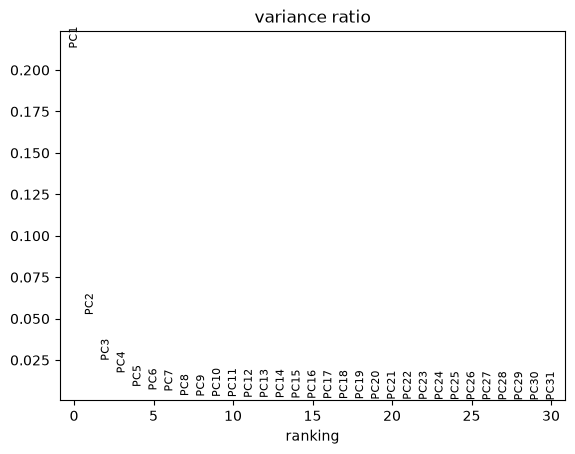

2026-08-31 09:51:37,867 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-08-31 09:51:37,869 - harmonypy - INFO -   Parameters:
2026-08-31 09:51:37,869 - harmonypy - INFO -     max_iter_harmony: 25
2026-08-31 09:51:37,869 - harmonypy - INFO -     max_iter_kmeans: 20
2026-08-31 09:51:37,870 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-08-31 09:51:37,870 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-08-31 09:51:37,870 - harmonypy - INFO -     nclust: 100
2026-08-31 09:51:37,870 - harmonypy - INFO -     block_size: 0.05
2026-08-31 09:51:37,871 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-08-31 09:51:37,871 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-08-31 09:51:37,872 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-08-31 09:51:37,872 - harmonypy - INFO -     verbose: True
2026-08-31 09:51:37,872 - harmonypy - INFO -     random_state: 0
2026-08-31 09:51:37,873 - harmon

finished harmony


In [5]:
# STEP 3: Get PCs and batch unmix the data
#sc.pp.pca(live_redo)
sc.pp.pca(adata)
sc.pl.pca_variance_ratio(adata)
#pcs_l = live_redo.obsm['X_pca']
pcs_d = adata.obsm['X_pca']
#print(pcs.shape)  # (n_cells, n_pcs)

# Run Harmony on the PCA embedding
#harmony_out_l = hm.run_harmony(pcs_l, live_redo.obs, "sample",max_iter_harmony=25)
harmony_out_d = hm.run_harmony(pcs_d, adata.obs, "sample",max_iter_harmony=25)


print("finished harmony")

# Store corrected PCs back in the AnnData object
#live_redo.obsm['X_pca_harmony'] = harmony_out_l.Z_corr
adata.obsm['X_pca_harmony'] = harmony_out_d.Z_corr
#sc.pp.neighbors(live_redo, use_rep='X_pca_harmony')
sc.pp.neighbors(adata, use_rep='X_pca_harmony')
#sc.tl.umap(live_redo)
sc.tl.umap(adata)

### Leiden Generation

if needed

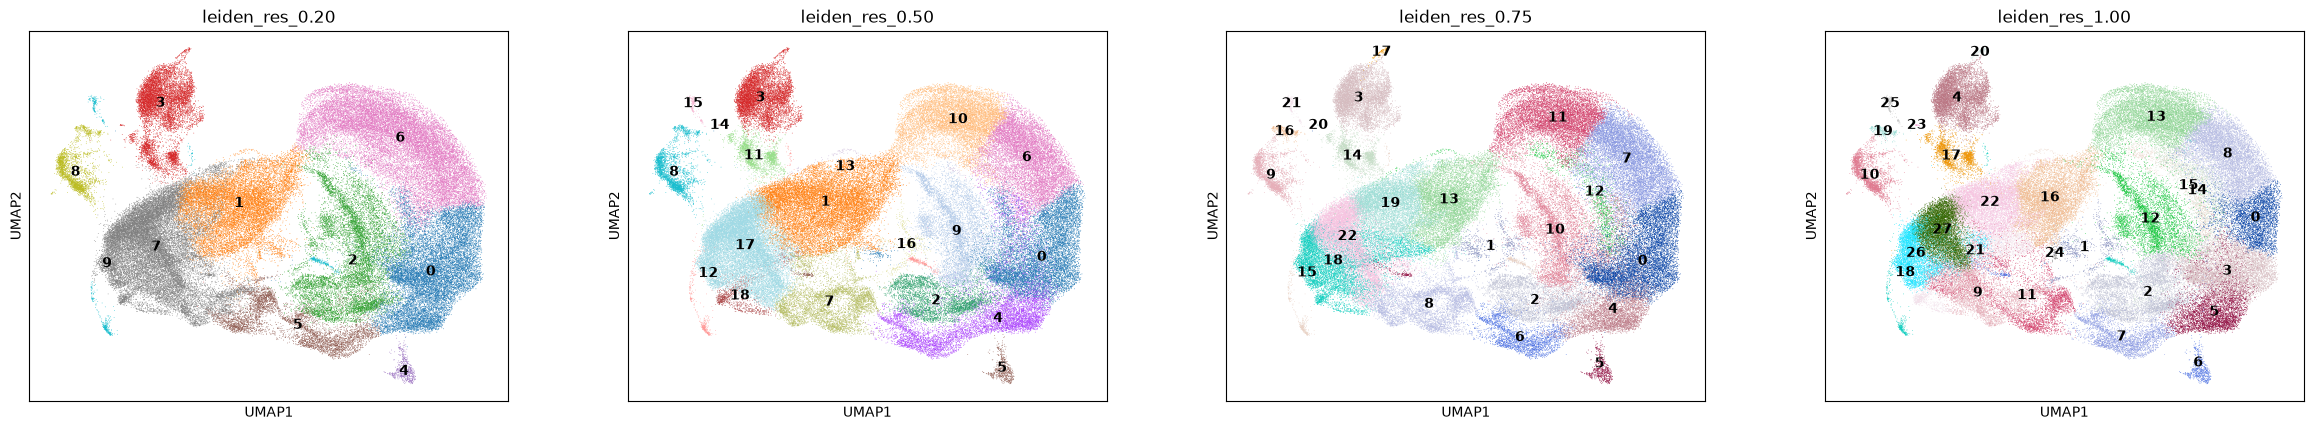

In [6]:
# STEP 3: GENERATE DIFFERENT RESOLUTIONS OF CLUSTERING

for res in [0.2, 0.5, 0.75, 1]:
    sc.tl.leiden(adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

sc.pl.umap(
    adata,
    color=["leiden_res_0.20", "leiden_res_0.50", "leiden_res_0.75", "leiden_res_1.00"],
    legend_loc="on data",
) 

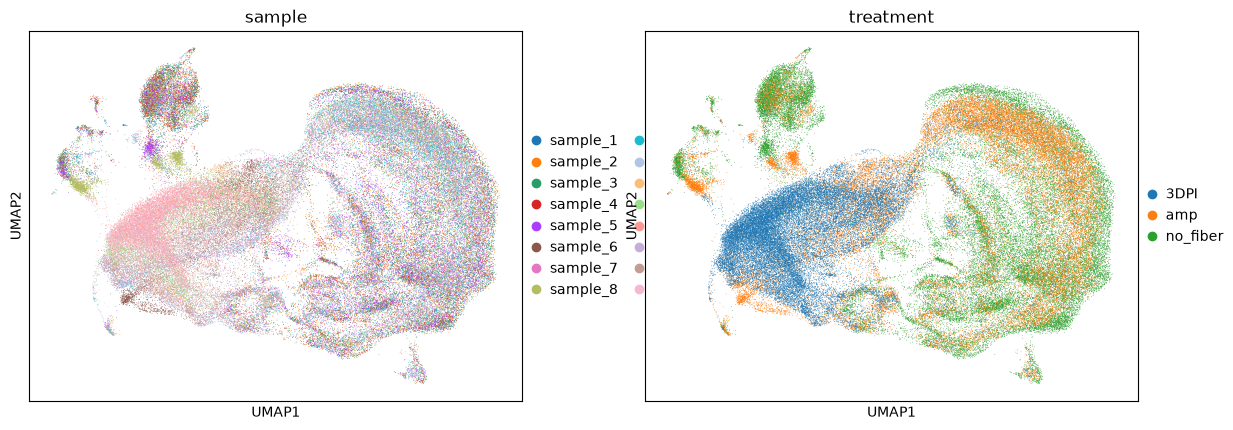

In [7]:
sc.pl.umap(adata,color=["sample","treatment"])

### Markers, Heatmaps, and Ranked DEG Dotplots

In [10]:
markers = ["Hoxb13","Slc26a3", "Npm1", "Aqp4", "Aqp8", "Cyp2c55", "Selenbp1", "Car1", "Cd79a","Chga", "Muc2", "Tff3", "Spink4", "Zg16", "Ccl6", "Mcpt1","Mcpt2","Sval1", "Lgr5", "Ascl2", "Cd3e", "Cd7", "Clca3b","Mki67", "Top2a", "Ube2c", "Dclk1"]
use_res = "1.00"

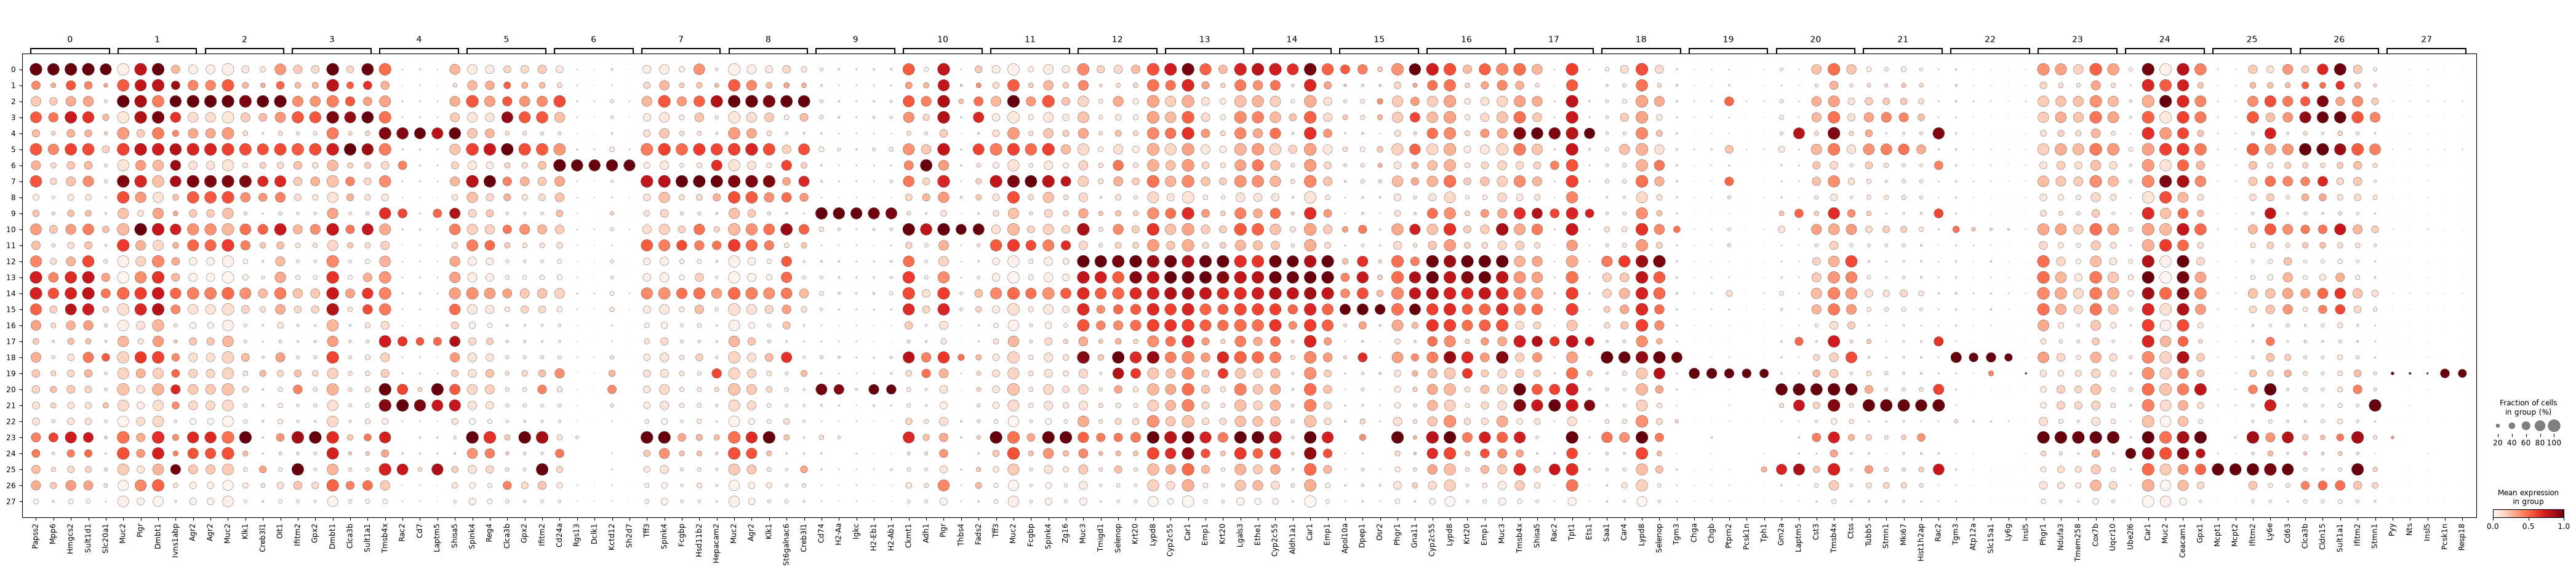

KeyError: "Could not find keys [np.str_('Cd79a')] in columns of `adata.obs` or in adata.var_names."

In [11]:
#plot a heatmap of given markers to assess cluster identity
sc.tl.rank_genes_groups(adata, groupby=f"leiden_res_{use_res}", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(adata, groupby=f"leiden_res_{use_res}", standard_scale="var", n_genes=5,dendrogram=False)
sc.pl.heatmap(adata,markers,groupby=f"leiden_res_{use_res}",figsize=(30,8),swap_axes=True)

In [ ]:
sc.pl.heatmap(adata,markers,groupby="cluster_cell_type",figsize=(30,8),swap_axes=True)

### UMAPs

In [ ]:
sc.pl.umap(adata,color=["Clca1"],mask_obs=adata.obs["treatment"] == "3DPI",cmap=ifitm_cmap,frameon=False,save="diet_clca1_3dpi_FINAL.svg")
sc.pl.umap(adata,color="Clca1",cmap=ifitm_cmap,frameon=False,save="diet_clca1_full_FINAL.svg")

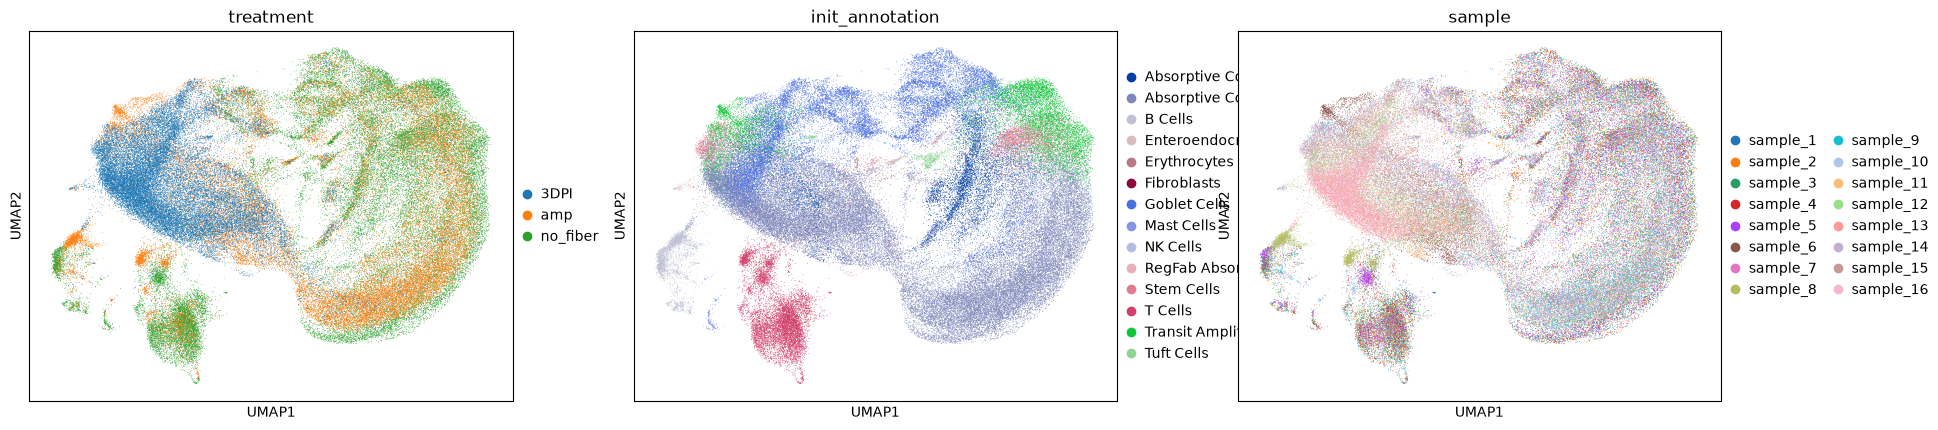

In [13]:
sc.pl.umap(adata,color=["treatment","init_annotation","sample"])

### Cluster Annotation

if needed

In [ ]:
cluster2annotation_d = {
    "0": "Absorptive Colonocytes",
    "1": "Absorptive Colonocytes",
    "2": "Goblet Cells",
    "3": "Absorptive Colonocyte Progenitors",
    "4": "Absorptive Colonocytes",
    "5": "T Cells",
    "6": "Tuft Cells",
    "7": "Goblet Cells",
    "8": "Transit Amplifying Cells",
    "9": "B Cells",
    "10": "Absorptive Colonocyte Progenitors",
    "11": "Goblet Cells",
    "12": "Enteroendocrine Cells",
    "13": "Stem Cells",
    "14": "T Cells",
    "15": "Absorptive Colonocytes",
    "16": "Goblet Cells",
    "17": "Goblet Cells",
    "18": "Goblet Cells",
    "19": "Absorptive Colonocytes",
    "20": "Absorptive Colonocytes",
    "21": "Absorptive Colonocytes",
    "22": "Absorptive Colonocytes",
    "23": "Tuft Cells",
    "24": "Goblet Cells",
    "25": "Mucosal Mast Cells",
    "26": "Absorptive Colonocytes",
}

adata.obs['cluster_cell_type'] = adata.obs["leiden_res_1.00"].map(cluster2annotation_d).astype('category')

### ISG Lists and Gene List Barplots

This example specifically built to pull all ISGs, but can be used with realistically any list of genes

In [ ]:
#Format the list to match mouse gene naming convention
all_isgs = ["ABTB2", "AC025171.1", "ADAM9", "ADAR", "AIDA", "AKR7A2", "ANKFY1", "AP3M2", "APOBEC3G", "APOL1", "APOL2", "APOL3", "APOL4", "APOL6", "ARAP2", "ARID3A", "ARID5B", "ARL4A", "ATP10A", "ATP6V0A4", "ATP6V0B", "AUTS2", "AVPR2", "B2M", "BAG1", "BAK1", "BANK1", "BATF2", "BAX", "BBC3", "BBX", "BCL2", "BCLAF1", "BPGM", "BRCA1", "BST2", "BTG1", "C1R", "C1S", "CALD1", "CALR", "CASP1", "CASP3", "CASP4", "CASP7", "CASP8", "CCDC91", "CCL2", "CCL5", "CCL7", "CCNYL1", "CCRL2", "CD164", "CD274", "CD38", "CD40", "CD47", "CD69", "CD74", "CD80", "CD86", "CDK1", "CDKN1A", "CDKN1B", "CEACAM1", "CEBPD", "CFB", "CFH", "CGAS", "CIITA", "CLIC4", "CMKLR1", "CMPK2", "CMTR1", "CNP", "COL16A1", "CSF1", "CSF2RB", "CSRP3", "CTR9", "CX3CL1", "CXCL10", "CXCL11", "CXCL9", "CYB561D2", "CYCS", "CYP24A1", "DCK", "DDIT4", "DDX1", "DDX17", "DDX21", "DDX58", "DDX60", "DHX58", "DNAJC2", "DTX3L", "E2F2", "EHD4", "EIF2AK2", "EIF2B1", "EIF3A", "EIF4E3", "ELF1", "ELK4", "EPRS1", "EPS15", "EPSTI1", "ETS2", "ETV7", "FAM111A", "FAM46A", "FAS", "FCGR1A", "FGL2", "FOSL1", "FPR1", "FUBP1", "GBP1", "GBP2", "GBP3", "GBP4", "GBP5", "GBP6", "GBP7", "GCH1", "GIMAP7", "GMFB", "GMPR", "GOLGA4", "GOLM1", "GPR18", "GZMA", "HADH", "HADHB", "HELZ2", "HERC5", "HERC6", "HIF1A", "HK2", "HLA-A", "HLA-B", "HLA-C", "HLA-DMA", "HLA-DPA1", "HLA-DQA1", "HLA-DQB1", "HLA-DRB1", "HLA-DRB3", "HLA-DRB4", "HLA-DRB5", "HLA-E", "HLA-F", "HLA-G", "HPSE", "HSD17B11", "HSH2D", "ICAM1", "IDO1", "IFI16", "IFI27", "IFI30", "IFI35", "IFI44", "IFI44L", "IFI6", "IFIH1", "IFIT1", "IFIT2", "IFIT3", "IFIT5", "IFITM1", "IFITM2", "IFITM3", "IFNAR2", "IL10RA", "IL12RB2", "IL15", "IL15RA", "IL18BP", "IL1RN", "IL23A", "IL2RB", "IL4R", "IL6", "IL7", "IQGAP1", "IRF1", "IRF2", "IRF4", "IRF5", "IRF7", "IRF8", "IRF9", "ISG15", "ISG20", "ISOC1", "ITGA2", "ITGA4", "ITGB7", "JADE2", "JAK2", "KLK3", "KLRK1", "KPTN", "LAMP3", "LAP3", "LAT", "LATS2", "LCP2", "LGALS3BP", "LGALS9", "LILRB1", "LINC01128", "LIPA", "LIPG", "LPAR6", "LRRC37A11P", "LY6E", "LYSMD2", "MAP1B", "MAP3K10", "MAP3K14", "MARCHF1", "MAX", "MB21D1", "METTL7B", "MIA3", "MLKL", "MMP25", "MOV10", "MS4A4A", "MS4A6A", "MT2A", "MTHFD2", "MVB12A", "MVP", "MX1", "MX2", "MXD4", "MYD88", "MYO1G", "NAMPT", "NAP1L1", "NCOA3", "NCOA7", "NFKB1", "NFKBIA", "NLRC5", "NMI", "NOD1", "NOS2", "NR4A3", "NT5C3A", "NUB1", "NUP93", "NUP98", "OAS1", "OAS2", "OAS3", "OASL", "OGFR", "P2RY14", "P2RY6", "PANK2", "PARP1", "PARP11", "PARP12", "PARP14", "PARP4", "PARP9", "PCGF5", "PDE4B", "PDXK", "PELI1", "PFKP", "PHB", "PHF11", "PIAS4", "PIK3AP1", "PIM1", "PLA1A", "PLA2G4A", "PLAAT4", "PLAUR", "PLOD2", "PLSCR1", "PMAIP1", "PML", "PNP", "PNPT1", "POLR2B", "PPA1", "PPM1K", "PPP3CA", "PPP5C", "PRAF2", "PRAME", "PRKCQ", "PROCR", "PSMA2", "PSMA3", "PSMB10", "PSMB2", "PSMB8", "PSMB9", "PSME1", "PSME2", "PTGS2", "PTPN1", "PTPN11", "PTPN2", "PTPN6", "PYHIN1", "RABL3", "RAC3", "RAPGEF6", "RBBP4", "RBCK1", "RBM43", "RBMX", "RFC2", "RHOC", "RIN2", "RIPK1", "RIPK2", "RNASEL", "RNF213", "RNF31", "RRP8", "RSAD2", "RTP4", "SAMD9", "SAMD9L", "SAMHD1", "SDC3", "SDCBP", "SECTM1", "SELL", "SELP", "SEM1", "SEPTIN4", "SERPING1", "SF3A1", "SKP1", "SLAMF7", "SLC15A3", "SLC25A28", "SLC39A8", "SLFN5", "SMAD4", "SMCHD1", "SOCS1", "SOCS3", "SOD2", "SP110", "SPPL2A", "SRI", "SRP9", "SRSF2", "SSBP1", "SSBP3", "SSPN", "ST3GAL5", "ST8SIA4", "STAT1", "STAT2", "STAT3", "STAT4", "SUN2", "TAP1", "TAPBP", "TDRD7", "TEAD1", "TEAD4", "TENT5A", "TIPARP", "TLK2", "TMEM106A", "TMEM140", "TMEM176A", "TNFAIP2", "TNFAIP3", "TNFAIP6", "TNFSF10", "TNIP3", "TOR1B", "TRAFD1", "TRAPPC10", "TREX1", "TRIM14", "TRIM21", "TRIM22", "TRIM25", "TRIM26", "TRIM5", "TTYH2", "TUBB", "TXNIP", "UBA7", "UBD", "UBE2D3", "UBE2L6", "UBE2Z", "UPP1", "USP18", "USP25", "VAMP5", "VAMP8", "VAT1", "VCAM1", "VCPIP1", "VEGFC", "WARS1", "XAF1", "XCL1", "XRCC6", "XRN1", "ZBP1", "ZC3HAV1", "ZCCHC2", "ZFP36L2", "ZNFX1"]
all_isgs_better = []
for isg in all_isgs:
    all_isgs_better.append(isg[0] + isg[1:].lower())
print(all_isgs_better)

In [ ]:
#generate master dictionary of all significant genes in gene list

all_genes = all_isgs_better

all_clus = adata.obs["cluster_cell_type"].cat.categories.tolist()

master_dict = {}

for clus in all_clus:
    print(f"getting clus {clus}")
    gene_dict = {}
    cluster_df = sc.get.rank_genes_groups_df(adata, group=clus)
    print(cluster_df.head())
    for gene in all_genes:
        try:
            lfc_value = cluster_df.loc[cluster_df['names'] == gene, 'logfoldchanges'].values[0]
            gene_dict[gene] = lfc_value
        except IndexError as e:
            pass
            #print(f"{gene} not present")
    master_dict[clus] = gene_dict

In [ ]:
#barplot of genes with fold change above zero
for clus_keys in master_dict.keys():
    final_dict = {}
    plt.figure(figsize=(30,6))
    plt.xticks(rotation=90)
    plt.title(f"{clus_keys}")
    sorted_dict = dict(sorted(master_dict[clus_keys].items(), key=lambda item: item[1],reverse=True))
    for keys, vals in sorted_dict.items():
        if vals > 0:
            final_dict[keys] = vals
    sns.barplot(final_dict,color="skyblue")
    sns.despine(top=True, right=True, left=True, bottom=True)
    plt.savefig(f"{clus_keys}_nofiber_isgs.svg",dpi=300,bbox_inches="tight")

### Generating a file of all DEGs per cluster per condition

This was a nightmare to unravel, new variable names are imminent

In [ ]:
#generate a DEG list of a specific cluster comparing two specific treatments

### ONLY EDIT THESE!!! ###

FILENAME = "20260820_dietONLY_DEG_final.txt"
CLUSTERING_OBS = "cluster_cell_type"
CONDITION = "treatment"
include_overlap = False

##########################

combined_vals = []
mhvy_only_vals = []
dhe_only_vals = []

amp_overlap = []
nf_overlap = []
total_overlap = []

expected_conditions = adata.obs[CONDITION].cat.categories.tolist()

##########################

with open(FILENAME,"w",encoding="utf-8") as f:
    for vclus in diet_clusters:
        print(adata[adata.obs[CLUSTERING_OBS] == vclus].obs[CONDITION].value_counts())
        if adata[adata.obs[CLUSTERING_OBS] == vclus].obs[CONDITION].cat.categories.tolist() != expected_conditions:
            print(f"NO CALCULATION FOR {vclus}, MISSING VALUES")
            f.write(f"NO CALCULATION FOR {vclus}, MISSING VALUES")
        else:
            diet_nf = adata[(adata.obs[CONDITION].isin(["no_fiber","3DPI"])) & (adata.obs[CLUSTERING_OBS] == vclus)]
            diet_amp = adata[(adata.obs[CONDITION].isin(["amp","3DPI"])) & (adata.obs[CLUSTERING_OBS] == vclus)]
            sc.tl.rank_genes_groups(diet_nf, groupby=CONDITION, method='wilcoxon',reference="no_fiber",key_added=f"diet_nf_{vclus}")
            sc.tl.rank_genes_groups(diet_amp, groupby=CONDITION, method='wilcoxon',reference="amp",key_added=f"diet_amp_{vclus}")
            df_diet_nf = sc.get.rank_genes_groups_df(diet_nf, group="3DPI",key=f"diet_nf_{vclus}")
            df_diet_amp = sc.get.rank_genes_groups_df(diet_amp, group="3DPI",key=f"diet_amp_{vclus}")
        
            sig_df_diet_amp_up = df_diet_amp[(df_diet_amp['pvals_adj'] < 0.05) & (df_diet_amp['logfoldchanges'] > 0)]
            sig_df_diet_amp_dw = df_diet_amp[(df_diet_amp['pvals_adj'] < 0.05) & (df_diet_amp['logfoldchanges'] < 0)]
            sig_df_diet_nf_up = df_diet_nf[(df_diet_nf['pvals_adj'] < 0.05) & (df_diet_nf['logfoldchanges'] > 0)]
            sig_df_diet_nf_dw = df_diet_nf[(df_diet_nf['pvals_adj'] < 0.05) & (df_diet_nf['logfoldchanges'] < 0)]
        
            diet_overlap_up = sig_df_diet_nf_up.loc[(sig_df_diet_nf_up['names'].isin(sig_df_diet_amp_up['names']))]
            diet_overlap_dw = sig_df_diet_nf_dw.loc[(sig_df_diet_nf_dw['names'].isin(sig_df_diet_amp_dw['names']))]
 
            f.write(f"DIET CLUSTER {vclus}:\n")
            f.write(f"Out of {len(sig_df_diet_amp_up)} total amp-up genes, \
            {len(sig_df_diet_amp_dw)} total amp-down genes, {len(sig_df_diet_nf_up)}\
            total no fiber-up genes, and {len(sig_df_diet_nf_dw)} total no fiber-down \n")

            if include_overlap:
                f.write(f"COMBINED UPREGULATED: {len(diet_combined_up['names'])}")
                f.write(diet_combined_up['names'].tolist())
                f.write(f"\n{vclus} OVERLAP UP: {len(diet_dhe_overlap_up['names'])}\n")
                f.write(str(diet_dhe_overlap_up['names'].tolist()))
                f.write(f"\n{vclus} OVERLAP DW: {len(diet_dhe_overlap_dw['names'])}\n")
                f.write(str(diet_dhe_overlap_dw['names'].tolist()))
            
            f.write(f"\n{vclus} NO FIBER UP\n")
            f.write(str(sig_df_diet_nf_up['names'].tolist()))
            f.write(f"\n{vclus} NO FIBER DW\n")
            f.write(str(sig_df_diet_nf_dw['names'].tolist()))
            f.write(f"\n{vclus} AMP UP\n")
            f.write(str(sig_df_diet_amp_up['names'].tolist()))
            f.write(f"\n{vclus} AMP DW\n")
            f.write(str(sig_df_diet_amp_dw['names'].tolist()))
    
    # for vclus in live_clusters:
    #     print(live_redo[live_redo.obs["cluster_cell_type"] == vclus].obs["treatment"].value_counts())
    #     if live_redo[live_redo.obs["cluster_cell_type"] == vclus].obs["treatment"].cat.categories.tolist() != ["5DPI","Mock"]:
    #         print(f"NO CALCULATION FOR {vclus}, MISSING VALUES")
    #         f.write(f"NO CALCULATION FOR {vclus}, MISSING VALUES")
    #     else:
    #         live_clus = live_redo[(live_redo.obs["treatment"].isin(["Mock","5DPI"])) & (live_redo.obs["cluster_cell_type"] == vclus)]
    #         sc.tl.rank_genes_groups(live_clus, groupby="treatment", method='wilcoxon',reference="Mock",key_added=f"live_{vclus}")
    #         df_live = sc.get.rank_genes_groups_df(live_clus, group="5DPI",key=f"live_{vclus}")
    #         sig_df_live_up = df_live[(df_live['pvals_adj'] < 0.05) & (df_live['logfoldchanges'] > 0)]
    #         sig_df_live_dw = df_live[(df_live['pvals_adj'] < 0.05) & (df_live['logfoldchanges'] < 0)]
        
    #         f.write(f"LIVE CLUSTER {vclus}:\n")
    #         f.write(f"\n{vclus} 5DPI UP (MOCK DW): {len(sig_df_live_up['names'])}\n")
    #         f.write(str(sig_df_live_up['names'].tolist()))
    #         f.write(f"\n{vclus} 5DPI DW (MOCK UP): {len(sig_df_live_dw['names'])}\n")
    #         f.write(str(sig_df_live_dw['names'].tolist()))